<a href="https://colab.research.google.com/github/chikuu303/customer-churn-ml-project/blob/main/credit_default_risk_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Default Risk Dataset

This notebook contains the dataset for **Task 3: Feature Engineering & Preprocessing Pipeline**.

The dataset is designed to demonstrate:
- Numerical and categorical features
- Missing values for imputation
- A binary target variable (`Default`)
- Data suitable for Scikit-Learn preprocessing and feature engineering

**Target:** `Default`  
**0:** No default  
**1:** Default


## Load the Dataset

In [47]:
import pandas as pd
import numpy as np

data = [
    [35,55000,720,"Graduate","Salaried",15000,"Married",0],
    [42,42000,610,"High School","Self-employed",25000,"Single",1],
    [29,68000,750,"Graduate","Salaried",10000,"Single",0],
    [51,38000,580,"High School","Unemployed",30000,"Married",1],
    [33,np.nan,790,"Postgraduate","Salaried",12000,"Married",0],

    # ... your remaining rows ...
]

In [75]:
# Visualize missing values

df = pd.DataFrame(data, columns=[
    "Age",
    "Income",
    "CreditScore",
    "Education",
    "EmploymentType",
    "LoanAmount",
    "MaritalStatus",
    "Default"
])

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (40, 8)


,Age,Income,CreditScore,Education,EmploymentType,LoanAmount,MaritalStatus,Default
0,35,55000.0,720.0,Graduate,Salaried,15000,Married,0
1,42,42000.0,610.0,High School,Self-employed,25000,Single,1
2,29,68000.0,750.0,Graduate,Salaried,10000,Single,0
3,51,38000.0,580.0,High School,Unemployed,30000,Married,1
4,33,NaN,790.0,Postgraduate,Salaried,12000,Married,0


In [49]:
# Separate features and target

X = df.drop("Default", axis=1)
y = df["Default"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (5, 7)
Target shape: (5,)


In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.feature_selection import mutual_info_classif

print("Libraries imported successfully!")

Libraries imported successfully!


In [51]:
import pandas as pd
import numpy as np

data = [
    [35,55000,720,"Graduate","Salaried",15000,"Married",0],
    [42,42000,610,"High School","Self-employed",25000,"Single",1],
    [29,68000,750,"Graduate","Salaried",10000,"Single",0],
    [51,38000,580,"High School","Unemployed",30000,"Married",1],
    [33,np.nan,790,"Postgraduate","Salaried",12000,"Married",0],
    [46,47000,640,"Graduate","Self-employed",22000,"Divorced",1],
    [27,50000,700,"Graduate","Salaried",9000,"Single",0],
    [39,61000,680,"Postgraduate","Salaried",18000,"Married",0],
    [55,35000,560,"High School","Unemployed",28000,"Married",1],
    [31,45000,630,np.nan,"Salaried",20000,"Single",1],
    [48,80000,810,"Postgraduate","Salaried",15000,"Married",0],
    [26,39000,590,"High School","Self-employed",17000,"Single",1],
    [37,58000,710,"Graduate","Salaried",13000,"Married",0],
    [44,52000,650,"Graduate","Self-employed",24000,"Divorced",1],
    [30,62000,730,"Postgraduate","Salaried",11000,"Single",0],
    [59,32000,540,"High School","Unemployed",35000,"Married",1],
    [41,67000,np.nan,"Graduate","Salaried",16000,"Married",0],
    [34,48000,620,"Graduate","Self-employed",21000,"Single",1],
    [28,57000,700,"Postgraduate","Salaried",8000,"Single",0],
    [50,43000,600,"High School","Self-employed",27000,"Married",1],
    [36,65000,740,"Graduate","Salaried",14000,"Married",0],
    [45,55000,660,"Graduate","Self-employed",23000,"Divorced",1],
    [32,71000,780,"Postgraduate","Salaried",10000,"Single",0],
    [53,40000,570,"High School",np.nan,32000,"Married",1],
    [38,59000,690,"Graduate","Salaried",17000,"Married",0],
    [29,46000,610,"High School","Self-employed",19000,"Single",1],
    [47,76000,800,"Postgraduate","Salaried",13000,"Married",0],
    [40,51000,670,"Graduate","Self-employed",26000,"Divorced",1],
    [25,60000,720,"Graduate","Salaried",7000,"Single",0],
    [56,37000,550,"High School","Unemployed",29000,"Married",1],
    [43,69000,770,"Postgraduate","Salaried",15000,"Married",0],
    [35,44000,600,"Graduate","Self-employed",22000,"Single",1],
    [31,63000,735,"Graduate","Salaried",9000,"Single",0],
    [49,49000,645,"High School","Self-employed",25000,"Divorced",1],
    [27,54000,710,"Postgraduate","Salaried",12000,"Single",0],
    [52,36000,565,"High School","Unemployed",31000,"Married",1],
    [39,73000,785,"Graduate","Salaried",16000,"Married",0],
    [33,47000,625,"Graduate","Self-employed",20000,"Single",1],
    [46,64000,750,"Postgraduate","Salaried",14000,"Married",0],
    [58,41000,580,"High School","Unemployed",33000,np.nan,1],
]

df = pd.DataFrame(data, columns=[
    "Age",
    "Income",
    "CreditScore",
    "Education",
    "EmploymentType",
    "LoanAmount",
    "MaritalStatus",
    "Default"
])

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (40, 8)


,Age,Income,CreditScore,Education,EmploymentType,LoanAmount,MaritalStatus,Default
0,35,55000.0,720.0,Graduate,Salaried,15000,Married,0
1,42,42000.0,610.0,High School,Self-employed,25000,Single,1
2,29,68000.0,750.0,Graduate,Salaried,10000,Single,0
3,51,38000.0,580.0,High School,Unemployed,30000,Married,1
4,33,NaN,790.0,Postgraduate,Salaried,12000,Married,0


## Dataset Inspection

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.feature_selection import mutual_info_classif

print("Libraries imported successfully!")

Libraries imported successfully!


In [53]:
# Dataset overview
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["Default"].value_counts())


Shape: (40, 8)

Data types:
Age                 int64
Income            float64
CreditScore       float64
Education          object
EmploymentType     object
LoanAmount          int64
MaritalStatus      object
Default             int64
dtype: object

Missing values:
Age               0
Income            1
CreditScore       1
Education         1
EmploymentType    1
LoanAmount        0
MaritalStatus     1
Default           0
dtype: int64

Target distribution:
Default
0    20
1    20
Name: count, dtype: int64


## Save as CSV

In [54]:
# Save the dataset as CSV if needed
df.to_csv("credit_default_risk.csv", index=False)
print("Saved as credit_default_risk.csv")


Saved as credit_default_risk.csv


In [55]:
print("Dataset shape:", df.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

Dataset shape: (40, 8)
X shape: (5, 7)
y shape: (5,)

Target values:
Default
0    3
1    2
Name: count, dtype: int64


In [56]:
print("df shape:", df.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst 10 rows of X:")
display(X.head(10))

print("\nTarget values:")
print(y.value_counts())

df shape: (40, 8)
X shape: (5, 7)
y shape: (5,)

First 10 rows of X:


,Age,Income,CreditScore,Education,EmploymentType,LoanAmount,MaritalStatus
0,35,55000.0,720,Graduate,Salaried,15000,Married
1,42,42000.0,610,High School,Self-employed,25000,Single
2,29,68000.0,750,Graduate,Salaried,10000,Single
3,51,38000.0,580,High School,Unemployed,30000,Married
4,33,NaN,790,Postgraduate,Salaried,12000,Married



Target values:
Default
0    3
1    2
Name: count, dtype: int64


In [57]:
# Create X and y again

X = df.drop("Default", axis=1)
y = df["Default"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (40, 7)
y shape: (40,)


In [58]:
# Create training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (32, 7)
Testing data: (8, 7)


In [59]:
# Create X and y

X = df.drop("Default", axis=1)
y = df["Default"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (40, 7)
y shape: (40,)


In [60]:
# Create training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (32, 7)
X_test: (8, 7)
y_train: (32,)
y_test: (8,)


In [61]:
# Identify numerical and categorical features

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Age', 'Income', 'CreditScore', 'LoanAmount']

Categorical Features:
['Education', 'EmploymentType', 'MaritalStatus']


In [62]:
# Numerical preprocessing pipeline

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

print("Numerical preprocessing pipeline created.")

Numerical preprocessing pipeline created.


In [63]:
# Categorical preprocessing pipeline

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

print("Categorical preprocessing pipeline created.")

Categorical preprocessing pipeline created.


In [64]:
# Categorical preprocessing pipeline

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

print("Categorical preprocessing pipeline created.")

Categorical preprocessing pipeline created.


In [65]:
# Combine numerical and categorical pipelines

preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

print("ColumnTransformer created successfully.")

ColumnTransformer created successfully.


In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.feature_selection import mutual_info_classif

print("Libraries imported successfully!")

Libraries imported successfully!


In [67]:
# Create Random Forest model

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

# Create complete reusable pipeline

full_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

print("Complete ML pipeline created successfully.")

Complete ML pipeline created successfully.


In [68]:
# Train the complete pipeline

full_pipeline.fit(X_train, y_train)

print("Pipeline trained successfully!")

Pipeline trained successfully!


In [69]:
# Make predictions on the test data

y_pred = full_pipeline.predict(X_test)

y_prob = full_pipeline.predict_proba(X_test)[:, 1]

print("Predictions completed successfully!")
print("Predicted values:", y_pred)

Predictions completed successfully!
Predicted values: [0 0 1 1 0 1 0 1]


In [70]:
# Evaluate the model

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("ROC-AUC:", roc_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0
ROC-AUC: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



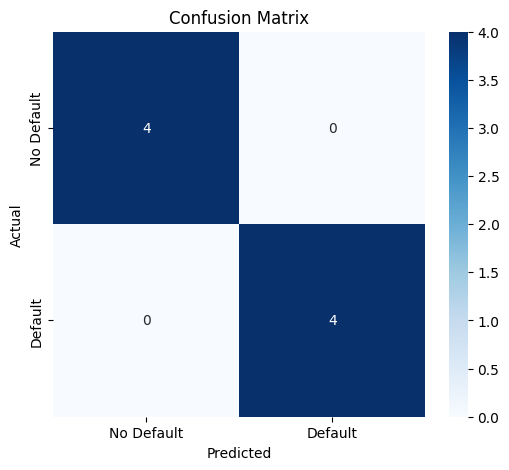

In [71]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [72]:
# Feature importance from Random Forest

feature_names = (
    full_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    full_pipeline
    .named_steps["model"]
    .feature_importances_
)

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    "Importance",
    ascending=False
)

display(feature_importance_df)

,Feature,Importance
2,numerical__CreditScore,0.229547
7,categorical__EmploymentType_Salaried,0.215825
3,numerical__LoanAmount,0.208029
1,numerical__Income,0.152496
8,categorical__EmploymentType_Self-employed,0.074853
5,categorical__Education_High School,0.041152
6,categorical__Education_Postgraduate,0.032664
10,categorical__MaritalStatus_Divorced,0.014162
0,numerical__Age,0.014078
9,categorical__EmploymentType_Unemployed,0.009091


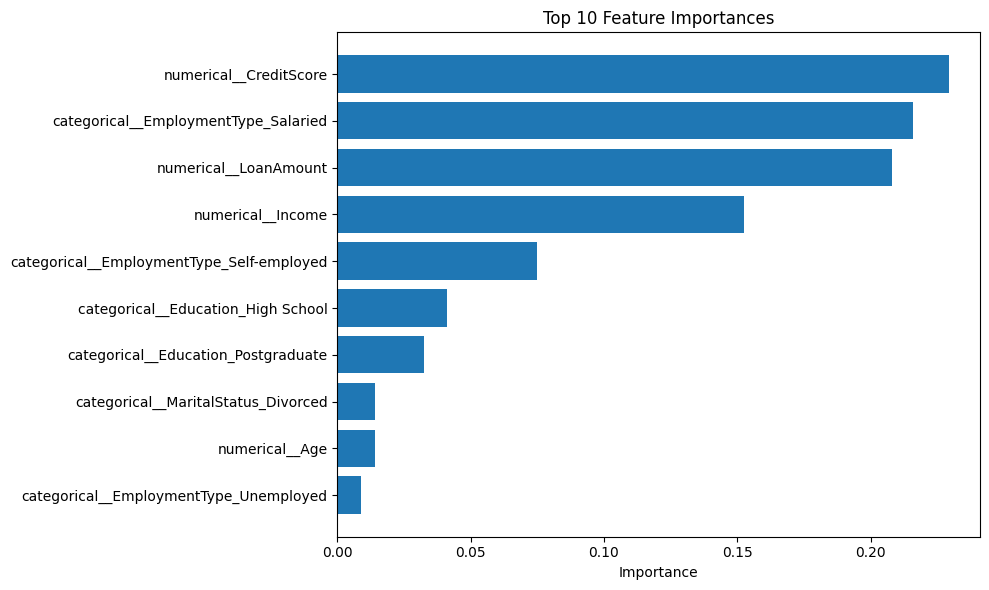

In [73]:
# Plot top 10 important features

top_features = feature_importance_df.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

In [74]:
# Mutual Information Feature Analysis

X_train_transformed = (
    full_pipeline
    .named_steps["preprocessor"]
    .transform(X_train)
)

feature_names = (
    full_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

mi_scores = mutual_info_classif(
    X_train_transformed,
    y_train,
    random_state=42
)

mi_df = pd.DataFrame({
    "Feature": feature_names,
    "Mutual Information": mi_scores
}).sort_values(
    "Mutual Information",
    ascending=False
)

display(mi_df)

,Feature,Mutual Information
2,numerical__CreditScore,0.626204
7,categorical__EmploymentType_Salaried,0.625836
3,numerical__LoanAmount,0.611236
1,numerical__Income,0.487414
8,categorical__EmploymentType_Self-employed,0.405322
5,categorical__Education_High School,0.402580
6,categorical__Education_Postgraduate,0.219717
9,categorical__EmploymentType_Unemployed,0.124866
11,categorical__MaritalStatus_Married,0.101402
4,categorical__Education_Graduate,0.084760


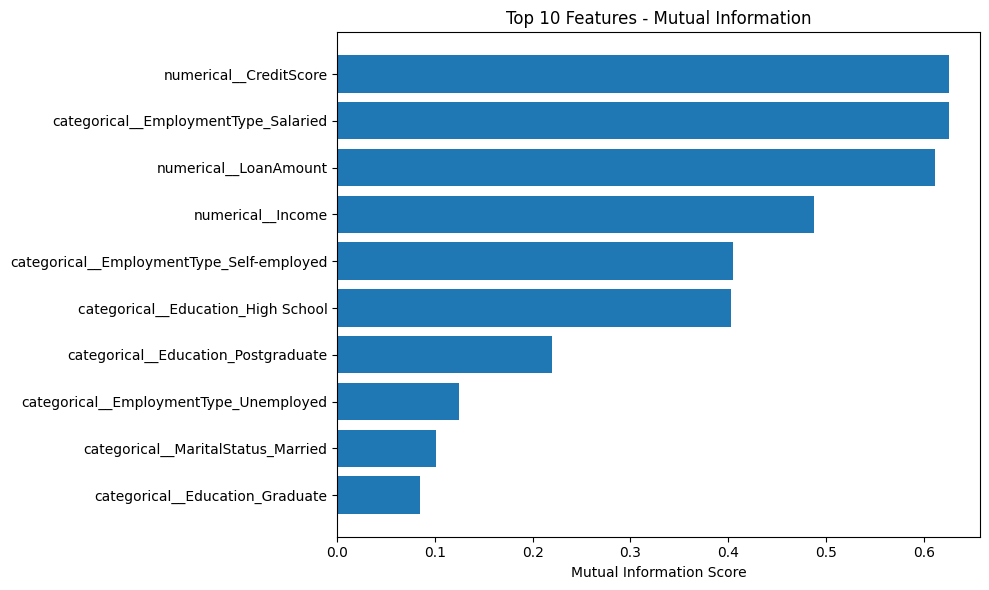

In [76]:
# Plot Mutual Information Scores

top_mi = mi_df.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_mi["Feature"],
    top_mi["Mutual Information"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Features - Mutual Information")
plt.xlabel("Mutual Information Score")

plt.tight_layout()
plt.show()

# Final Conclusion

This project implemented a complete Feature Engineering and Preprocessing Pipeline for a Credit Default Risk dataset.

The dataset was first divided into training and testing sets before any preprocessing to prevent data leakage. Numerical features were processed using median imputation and StandardScaler, while categorical features were processed using most-frequent imputation and One-Hot Encoding.

A Scikit-Learn `ColumnTransformer` was used to combine the numerical and categorical preprocessing steps. These transformations were then combined with a Random Forest classifier inside a reusable Scikit-Learn `Pipeline`.

The model was evaluated using accuracy, ROC-AUC, classification report, and a confusion matrix. Feature importance from the Random Forest model and Mutual Information scores were also calculated to identify influential features.

Overall, the notebook demonstrates a reusable and leakage-safe machine learning preprocessing workflow using Scikit-Learn.
